# Experiment 10: Customer Segmentation (Case Study)

## Objective
Build customer segments using transaction data from an online retail dataset.

## Workflow
1. Load and inspect data
2. Clean and prepare transaction records
3. Create customer-level RFM features
4. Apply K-Means clustering
5. Interpret customer segments and suggest business actions

In [1]:
# Imports
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

In [2]:
# Load dataset (checks likely locations in your workspace)
possible_paths = [
    Path("data_online_retail.csv"),
    Path("../data_online_retail.csv"),
    Path("../../data_online_retail.csv"),
    Path("exp08/data_online_retail.csv"),
]

data_path = next((p for p in possible_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Could not find data_online_retail.csv in expected locations.")

print(f"Using file: {data_path.resolve()}")

# Use latin1 for compatibility with common Online Retail dataset encoding
df = pd.read_csv(data_path, encoding="latin1")
print(f"Shape: {df.shape}")
display(df.head())
print("\nColumns:")
print(df.columns.tolist())

Using file: C:\Users\Anshul Parkar\Documents\GitHub\ADS_Sem8_labCodes\data_online_retail.csv
Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom



Columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


## Data Cleaning and Transaction Preparation
We keep valid purchases and derive monetary value per transaction.

Cleaning choices:
- Convert `InvoiceDate` to datetime
- Remove rows with missing `CustomerID`
- Keep only positive `Quantity` and `UnitPrice`
- Remove cancellation invoices (InvoiceNo starting with `C`)

In [3]:
# Clean dataset and engineer transaction amount
work_df = df.copy()

# Normalize key columns if present
required_cols = ["InvoiceNo", "Quantity", "InvoiceDate", "UnitPrice", "CustomerID"]
missing = [c for c in required_cols if c not in work_df.columns]
if missing:
    raise ValueError(f"Dataset missing required columns: {missing}")

work_df["InvoiceDate"] = pd.to_datetime(work_df["InvoiceDate"], errors="coerce")
work_df = work_df.dropna(subset=["CustomerID", "InvoiceDate"])

# Remove canceled invoices and invalid transactions
work_df = work_df[~work_df["InvoiceNo"].astype(str).str.startswith("C", na=False)]
work_df = work_df[(work_df["Quantity"] > 0) & (work_df["UnitPrice"] > 0)]

work_df["CustomerID"] = work_df["CustomerID"].astype(str)
work_df["Amount"] = work_df["Quantity"] * work_df["UnitPrice"]

print(f"Rows after cleaning: {len(work_df):,}")
print(f"Unique customers: {work_df['CustomerID'].nunique():,}")
display(work_df.head())

Rows after cleaning: 397,884
Unique customers: 4,338


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Amount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [4]:
# Build RFM features at customer level
snapshot_date = work_df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = work_df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("Amount", "sum"),
).reset_index()

print(f"RFM table shape: {rfm.shape}")
display(rfm.head())

display(rfm[["Recency", "Frequency", "Monetary"]].describe().T)

RFM table shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


,count,mean,std,min,25%,50%,75%,max
Recency,4338.0,92.536422,100.014169,1.00,18.000,51.000,142.00,374.00
Frequency,4338.0,4.272015,7.697998,1.00,1.000,2.000,5.00,209.00
Monetary,4338.0,2054.266460,8989.230441,3.75,307.415,674.485,1661.74,280206.02


Selected k (best silhouette): 3


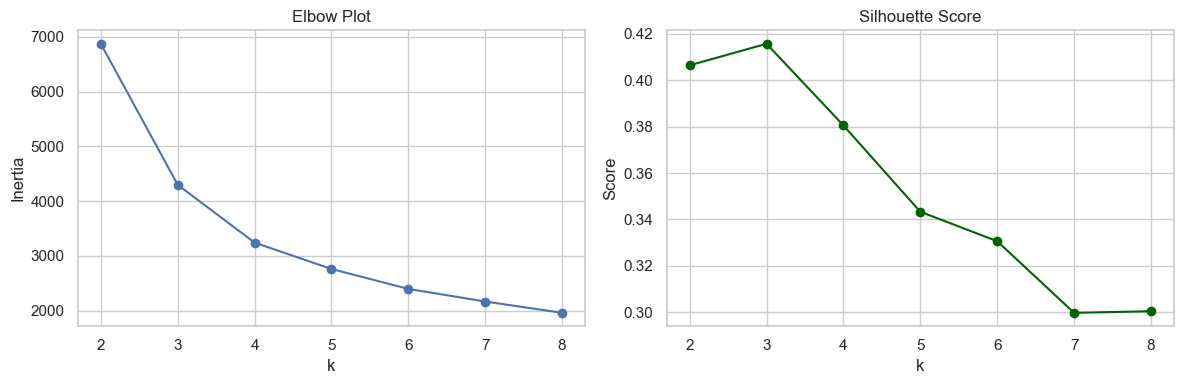

In [5]:
# Scale features and select cluster count using silhouette score
features = ["Recency", "Frequency", "Monetary"]
X = rfm[features].copy()

# Log transform skewed features for better clustering behavior
X["Frequency"] = np.log1p(X["Frequency"])
X["Monetary"] = np.log1p(X["Monetary"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k_values = list(range(2, 9))
inertias = []
sil_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels_k))

best_k = k_values[int(np.argmax(sil_scores))]
print(f"Selected k (best silhouette): {best_k}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_values, inertias, marker="o")
axes[0].set_title("Elbow Plot")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

axes[1].plot(k_values, sil_scores, marker="o", color="darkgreen")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Score")

plt.tight_layout()
plt.show()

Segment sizes:


,Customers
Segment,
0,2036
1,1323
2,979


Average RFM by segment:


,Recency,Frequency,Monetary
Segment,,,
0,54.86,2.05,615.24
1,30.10,9.83,5494.34
2,255.27,1.39,398.13


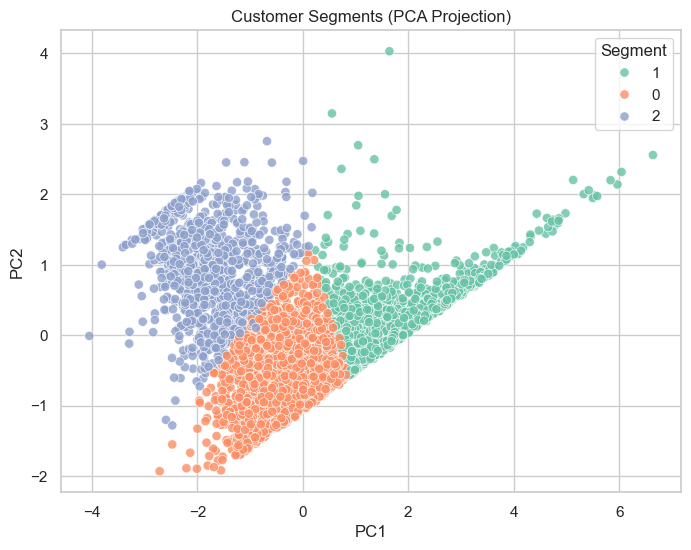

In [6]:
# Final K-Means model and segment labeling
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
rfm["Segment"] = kmeans.fit_predict(X_scaled)

segment_profile = rfm.groupby("Segment")[["Recency", "Frequency", "Monetary"]].mean().round(2)
segment_size = rfm["Segment"].value_counts().sort_index()

print("Segment sizes:")
display(segment_size.to_frame("Customers"))

print("Average RFM by segment:")
display(segment_profile)

# 2D PCA projection for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

viz_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Segment": rfm["Segment"].astype(str),
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=viz_df, x="PC1", y="PC2", hue="Segment", palette="Set2", s=45, alpha=0.8)
plt.title("Customer Segments (PCA Projection)")
plt.legend(title="Segment")
plt.show()

In [7]:
# Segment interpretation and business recommendations
profile = segment_profile.copy()

# Relative ranks to infer business meaning
profile["Recency_rank"] = profile["Recency"].rank(ascending=True)
profile["Frequency_rank"] = profile["Frequency"].rank(ascending=False)
profile["Monetary_rank"] = profile["Monetary"].rank(ascending=False)

segment_labels = {}
for seg, row in profile.iterrows():
    if row["Recency_rank"] <= 1.5 and row["Frequency_rank"] <= 1.5 and row["Monetary_rank"] <= 1.5:
        segment_labels[seg] = "Champions"
    elif row["Recency_rank"] <= 2.5 and row["Frequency_rank"] <= 2.5:
        segment_labels[seg] = "Loyal Customers"
    elif row["Recency_rank"] >= (len(profile) - 0.5):
        segment_labels[seg] = "At Risk"
    else:
        segment_labels[seg] = "Potential"

rfm["SegmentName"] = rfm["Segment"].map(segment_labels)

summary = (
    rfm.groupby(["Segment", "SegmentName"])[["Recency", "Frequency", "Monetary"]]
    .mean()
    .round(2)
    .reset_index()
)

print("Named segment summary:")
display(summary)

recommendations = {
    "Champions": "Reward with premium offers, early access, and referral programs.",
    "Loyal Customers": "Use retention campaigns, cross-sell relevant products, and subscriptions.",
    "At Risk": "Run win-back campaigns with personalized discounts and reminders.",
    "Potential": "Nurture using onboarding offers and product discovery journeys.",
}

print("\nRecommended Actions:")
for name in sorted(rfm["SegmentName"].dropna().unique()):
    print(f"- {name}: {recommendations.get(name, 'Design campaign based on behavior profile.')}")

Named segment summary:


,Segment,SegmentName,Recency,Frequency,Monetary
0,0,Loyal Customers,54.86,2.05,615.24
1,1,Champions,30.10,9.83,5494.34
2,2,At Risk,255.27,1.39,398.13



Recommended Actions:
- At Risk: Run win-back campaigns with personalized discounts and reminders.
- Champions: Reward with premium offers, early access, and referral programs.
- Loyal Customers: Use retention campaigns, cross-sell relevant products, and subscriptions.


## Conclusion
This case study demonstrates customer segmentation using RFM features and K-Means clustering.

Expected deliverables for Experiment 10:
- Segment definitions based on transaction behavior
- Visual representation of cluster separation
- Actionable marketing strategies for each customer segment